# 🌸 Flower Image Classification Using Convolutional Neural Network (CNN)

## 📌 Project Overview

In this project, we will build a **Convolutional Neural Network (CNN)** from scratch
to classify flower images into different categories.

The project covers the complete deep learning workflow, including:

- Image dataset exploration
- Image preprocessing
- Train, validation, and test split
- Data augmentation
- CNN architecture design
- Model training
- Model evaluation
- Confusion matrix
- Classification report
- Single-image prediction
- Model saving
- Streamlit deployment

### 🧠 Model

**Convolutional Neural Network (CNN)**

### 🛠️ Technologies

- Python
- TensorFlow
- Keras
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn
- PIL
- Streamlit

### 🎯 Objective

The main objective of this project is to develop a CNN-based image classification
model capable of recognizing different types of flowers from their images.

# 1. Import Required Libraries

In this project, we will use TensorFlow/Keras for building and training
the CNN model.

We will also use NumPy, Matplotlib, Seaborn, PIL, and Scikit-learn
for data processing, visualization, and model evaluation.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


# 2. Define Dataset Path

The flower images are stored locally in the following directory:

`F:\Anas\Dataset\flower_images`

We will use `pathlib.Path` to handle the Windows directory path.

In [2]:
dataset_path = Path(
    r"F:\Anas\Dataset\flower_images"
)

print("Dataset Path:")
print(dataset_path)

print("\nPath Exists:", dataset_path.exists())

Dataset Path:
F:\Anas\Dataset\flower_images

Path Exists: True


# 3. Explore Dataset Structure

Before building the CNN, we need to understand how the dataset
is organized.

Each flower category should be stored inside its own directory.

In [3]:
folders = [
    folder for folder in dataset_path.iterdir()
    if folder.is_dir()
]

print("Number of Classes:", len(folders))

print("\nClasses:")

for folder in folders:
    print(folder.name)

Number of Classes: 5

Classes:
Lilly
Lotus
Orchid
Sunflower
Tulip


# 4. Analyze Images Per Class

In this step, we will calculate the number of images available
in each flower category.

This helps us determine whether the dataset is balanced or imbalanced.

In [4]:
class_counts = {}

for folder in folders:

    image_files = [
        file for file in folder.iterdir()
        if file.suffix.lower() in [
            ".jpg",
            ".jpeg",
            ".png"
        ]
    ]

    class_counts[folder.name] = len(image_files)

class_counts

{'Lilly': 999, 'Lotus': 1000, 'Orchid': 1000, 'Sunflower': 1000, 'Tulip': 1000}

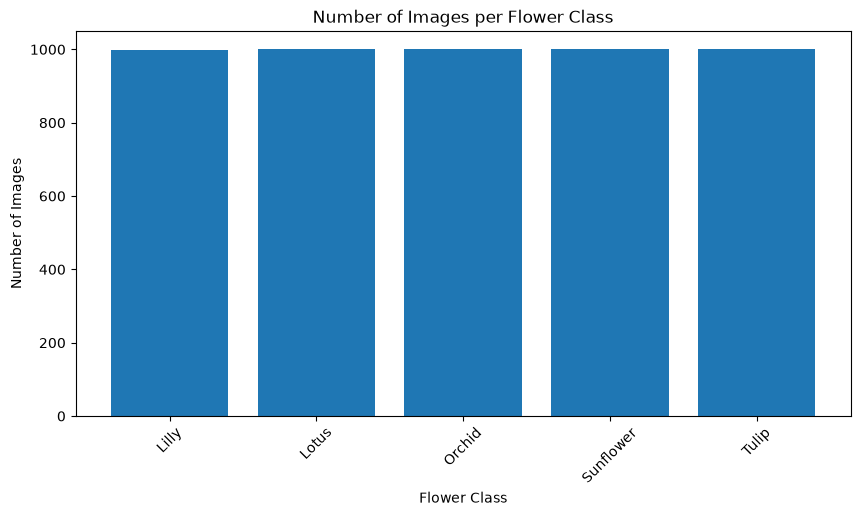

In [5]:
plt.figure(figsize=(10, 5))

plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.xlabel("Flower Class")
plt.ylabel("Number of Images")
plt.title("Number of Images per Flower Class")

plt.xticks(rotation=45)

plt.show()

# 5. Visualize Sample Images

Before preprocessing the dataset, we will visualize sample images
from each flower category.

This allows us to understand the visual characteristics of the
different classes.

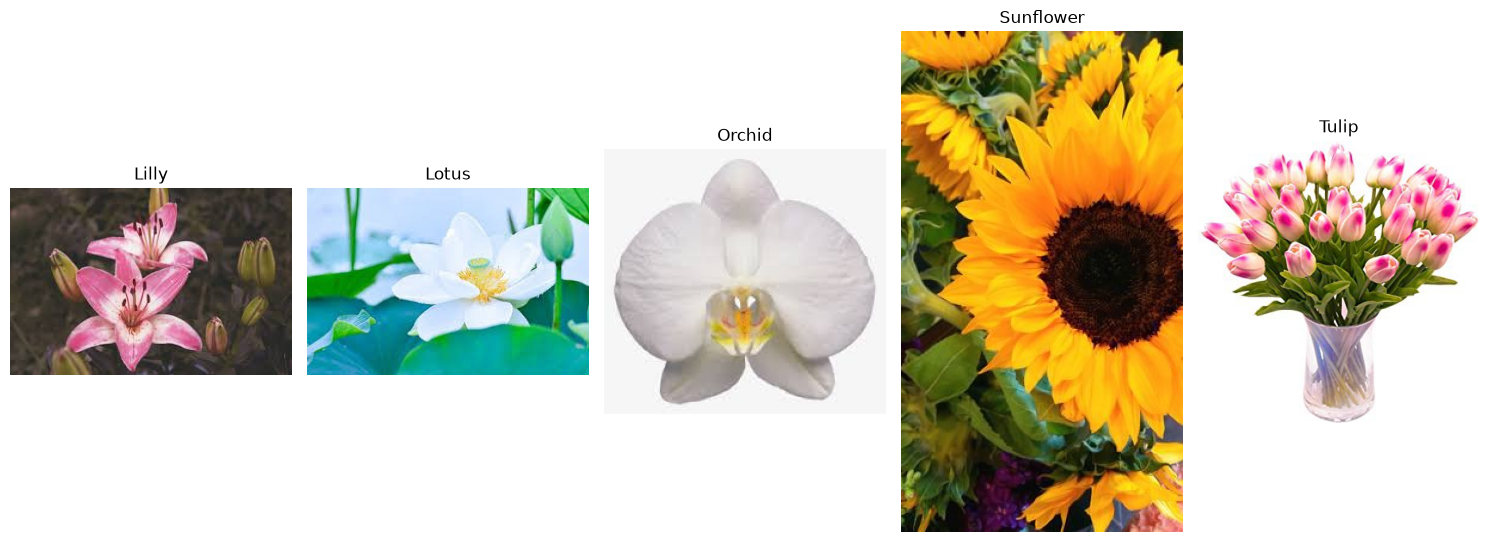

In [6]:
plt.figure(figsize=(15, 8))

for i, folder in enumerate(folders):

    image_files = [
        file for file in folder.iterdir()
        if file.suffix.lower() in [
            ".jpg",
            ".jpeg",
            ".png"
        ]
    ]

    if image_files:

        image = Image.open(image_files[0])

        plt.subplot(1, len(folders), i + 1)

        plt.imshow(image)

        plt.title(folder.name)

        plt.axis("off")

plt.tight_layout()

plt.show()

# 6. Create Train, Validation, and Test Sets

The dataset will be divided into three subsets:

- Training Set → Used to train the CNN
- Validation Set → Used to monitor model performance during training
- Test Set → Used for final evaluation

We will use:

- 70% Training
- 15% Validation
- 15% Testing

In [7]:
image_paths = []
labels = []

for folder in folders:

    image_files = [
        file for file in folder.iterdir()
        if file.suffix.lower() in [
            ".jpg",
            ".jpeg",
            ".png"
        ]
    ]

    for image_file in image_files:

        image_paths.append(str(image_file))
        labels.append(folder.name)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

print("Total Images:", len(df))

df.head()

Total Images: 4999


,image_path,label
0,F:\Anas\Dataset\flower_images\Lilly\00048a5c76...,Lilly
1,F:\Anas\Dataset\flower_images\Lilly\001ff6644e...,Lilly
2,F:\Anas\Dataset\flower_images\Lilly\001ff6656j...,Lilly
3,F:\Anas\Dataset\flower_images\Lilly\00973ad1b1...,Lilly
4,F:\Anas\Dataset\flower_images\Lilly\00a7d512d6...,Lilly


In [8]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Training Images:", len(train_df))
print("Validation Images:", len(val_df))
print("Testing Images:", len(test_df))

Training Images: 3499
Validation Images: 750
Testing Images: 750


# 7. Image Preprocessing

CNN models require images to have a consistent shape.

Therefore, every image will be:

1. Loaded
2. Converted to RGB
3. Resized to 224 × 224 pixels
4. Converted into a numerical tensor
5. Normalized before being passed to the CNN

In [9]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = len(folders)

print("Image Size:", IMG_SIZE)
print("Batch Size:", BATCH_SIZE)
print("Number of Classes:", NUM_CLASSES)

Image Size: (224, 224)
Batch Size: 32
Number of Classes: 5


In [10]:
class_names = sorted(
    df["label"].unique()
)

print(class_names)

['Lilly', 'Lotus', 'Orchid', 'Sunflower', 'Tulip']


# 8. Create TensorFlow Dataset

We will convert the image paths and labels into TensorFlow datasets.

Using `tf.data.Dataset` allows TensorFlow to efficiently load,
preprocess, batch, and feed images to the CNN during training.

In [11]:
class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

class_to_index

{'Lilly': 0, 'Lotus': 1, 'Orchid': 2, 'Sunflower': 3, 'Tulip': 4}

In [12]:
def create_dataset(dataframe):

    paths = dataframe["image_path"].values

    labels = dataframe["label"].map(
        class_to_index
    ).values

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    return dataset

In [13]:
train_ds = create_dataset(train_df)
val_ds = create_dataset(val_df)
test_ds = create_dataset(test_df)

# 9. Build Image Preprocessing Pipeline

Each image will be loaded from its file path and transformed into
a tensor suitable for the CNN.

The preprocessing pipeline performs:

- Image loading
- JPEG/PNG decoding
- RGB conversion
- Resizing
- Pixel normalization

In [14]:
def preprocess_image(image_path, label):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    ) / 255.0

    return image, label

In [15]:
train_ds = train_ds.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

# 10. Data Augmentation

Deep learning models can overfit when the training dataset is limited.

To improve generalization, we will apply data augmentation to the
training images.

The augmentation techniques include:

- Random horizontal flipping
- Random rotation
- Random zoom
- Random contrast

These transformations generate slightly different versions of
training images while preserving their class labels.

In [16]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip(
            "horizontal"
        ),

        layers.RandomRotation(
            0.1
        ),

        layers.RandomZoom(
            0.1
        ),

        layers.RandomContrast(
            0.1
        )
    ],
    name="data_augmentation"
)

In [17]:
train_ds = train_ds.shuffle(
    buffer_size=1000
)

train_ds = train_ds.batch(
    BATCH_SIZE
)

val_ds = val_ds.batch(
    BATCH_SIZE
)

test_ds = test_ds.batch(
    BATCH_SIZE
)

train_ds = train_ds.prefetch(
    tf.data.AUTOTUNE
)

val_ds = val_ds.prefetch(
    tf.data.AUTOTUNE
)

test_ds = test_ds.prefetch(
    tf.data.AUTOTUNE
)

# 11. Build the Convolutional Neural Network (CNN)

In this section, we will build a custom Convolutional Neural Network (CNN)
for flower image classification.

The CNN will learn visual features from the images through multiple
convolutional and pooling layers.

### CNN Architecture

The model will contain:

- Convolutional layers for feature extraction
- ReLU activation functions
- MaxPooling layers for dimensionality reduction
- Flatten layer to convert feature maps into a vector
- Dense layers for classification
- Dropout layer to reduce overfitting
- Softmax output layer for multiclass classification

In [18]:
model = keras.Sequential([
    
    # Input
    layers.Input(shape=(224, 224, 3)),
    
    # Data Augmentation
    data_augmentation,
    
    # Convolution Block 1
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    
    layers.MaxPooling2D(
        (2, 2)
    ),
    
    # Convolution Block 2
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    
    layers.MaxPooling2D(
        (2, 2)
    ),
    
    # Convolution Block 3
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    
    layers.MaxPooling2D(
        (2, 2)
    ),
    
    # Convolution Block 4
    layers.Conv2D(
        256,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    
    layers.MaxPooling2D(
        (2, 2)
    ),
    
    # Flatten
    layers.Flatten(),
    
    # Fully Connected Layer
    layers.Dense(
        256,
        activation="relu"
    ),
    
    # Dropout
    layers.Dropout(
        0.5
    ),
    
    # Output Layer
    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
    
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,235,013 (50.49 MB)

 Trainable params: 13,235,013 (50.49 MB)

 Non-trainable params: 0 (0.00 B)

# 12. Compile the CNN Model

Before training the model, we need to compile it.

We will use:

- Adam optimizer
- Sparse Categorical Crossentropy loss
- Accuracy as the evaluation metric

The Adam optimizer will update the model weights during training,
while sparse categorical crossentropy will measure the classification error.

In [19]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    
    loss="sparse_categorical_crossentropy",
    
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


# 13. Train the CNN Model

The CNN will now be trained using the training dataset.

The validation dataset will be used to monitor the model's performance
on unseen images during training.

The training history will be stored for further analysis.

In [20]:
EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/20


f:\Anas\DATA_SCIENCE_POTPOLIO\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


110/110 ━━━━━━━━━━━━━━━━━━━━ 49s 412ms/step - accuracy: 0.4133 - loss: 1.3920 - val_accuracy: 0.5093 - val_loss: 1.1612
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 44s 397ms/step - accuracy: 0.5307 - loss: 1.1717 - val_accuracy: 0.5933 - val_loss: 1.1051
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 44s 395ms/step - accuracy: 0.5596 - loss: 1.0858 - val_accuracy: 0.6013 - val_loss: 1.0115
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 43s 384ms/step - accuracy: 0.5936 - loss: 1.0394 - val_accuracy: 0.6227 - val_loss: 0.9311
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 44s 393ms/step - accuracy: 0.6262 - loss: 0.9579 - val_accuracy: 0.6467 - val_loss: 0.8774
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.6579 - loss: 0.8931 - val_accuracy: 0.6733 - val_loss: 0.8730
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.6499 - loss: 0.8863 - val_accuracy: 0.6613 - val_loss: 0.8432
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 79s 711ms/step - accuracy: 0.6876 - loss: 0.8156 - val_acc

# 14. Training and Validation Accuracy

We will visualize the training and validation accuracy across epochs.

This allows us to determine whether the model is learning effectively
and whether overfitting is occurring.

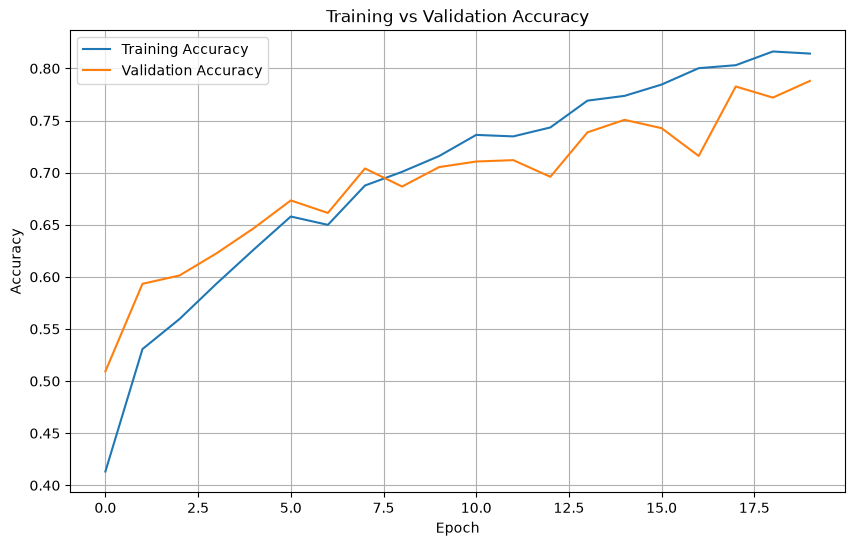

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()

plt.grid()

plt.show()

# 15. Training and Validation Loss

The loss curves show how the classification error changes during training.

A decreasing training and validation loss generally indicates that the
model is learning useful patterns from the dataset.

A large difference between training and validation loss may indicate
overfitting.

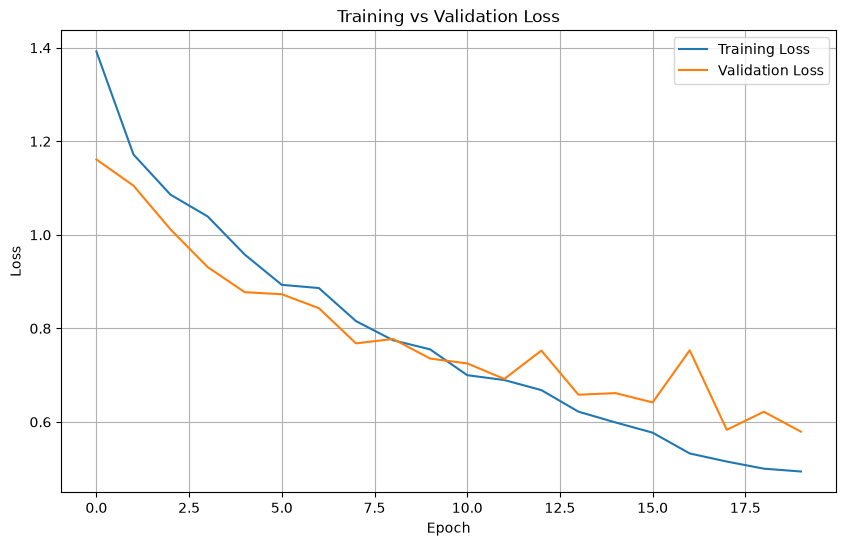

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()

plt.grid()

plt.show()

# 16. Evaluate the CNN on Test Data

The test dataset contains images that were not used during training.

We will use this dataset to measure how well the CNN generalizes
to completely unseen images.

In [23]:
test_loss, test_accuracy = model.evaluate(
    test_ds
)

print(
    f"Test Loss: {test_loss:.4f}"
)

print(
    f"Test Accuracy: {test_accuracy:.4f}"
)

print(
    f"Test Accuracy: {test_accuracy * 100:.2f}%"
)

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.7880 - loss: 0.6405
Test Loss: 0.6405
Test Accuracy: 0.7880
Test Accuracy: 78.80%


# 17. Generate Predictions on Test Data

The trained CNN produces a probability distribution for each image.

The class with the highest probability will be selected as the
predicted flower category.

In [24]:
y_true = []
y_pred = []

for images, labels in test_ds:
    
    predictions = model.predict(
        images,
        verbose=0
    )
    
    predicted_classes = np.argmax(
        predictions,
        axis=1
    )
    
    y_true.extend(
        labels.numpy()
    )
    
    y_pred.extend(
        predicted_classes
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated successfully!")

print("Actual labels shape:", y_true.shape)
print("Predicted labels shape:", y_pred.shape)

Predictions generated successfully!
Actual labels shape: (750,)
Predicted labels shape: (750,)


# 18. Classification Report

The classification report provides detailed performance metrics
for each flower category.

The report contains:

- Precision
- Recall
- F1-score
- Support

These metrics provide a more detailed evaluation than accuracy alone.

In [25]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

       Lilly       0.71      0.62      0.66       150
       Lotus       0.81      0.80      0.81       150
      Orchid       0.70      0.83      0.76       150
   Sunflower       0.88      0.97      0.93       150
       Tulip       0.84      0.72      0.77       150

    accuracy                           0.79       750
   macro avg       0.79      0.79      0.79       750
weighted avg       0.79      0.79      0.79       750



# 19. Confusion Matrix

The confusion matrix shows how the CNN classified images from each
flower category.

The diagonal values represent correct predictions, while the
off-diagonal values represent misclassifications.

This helps us identify which flower categories are difficult
for the model to distinguish.

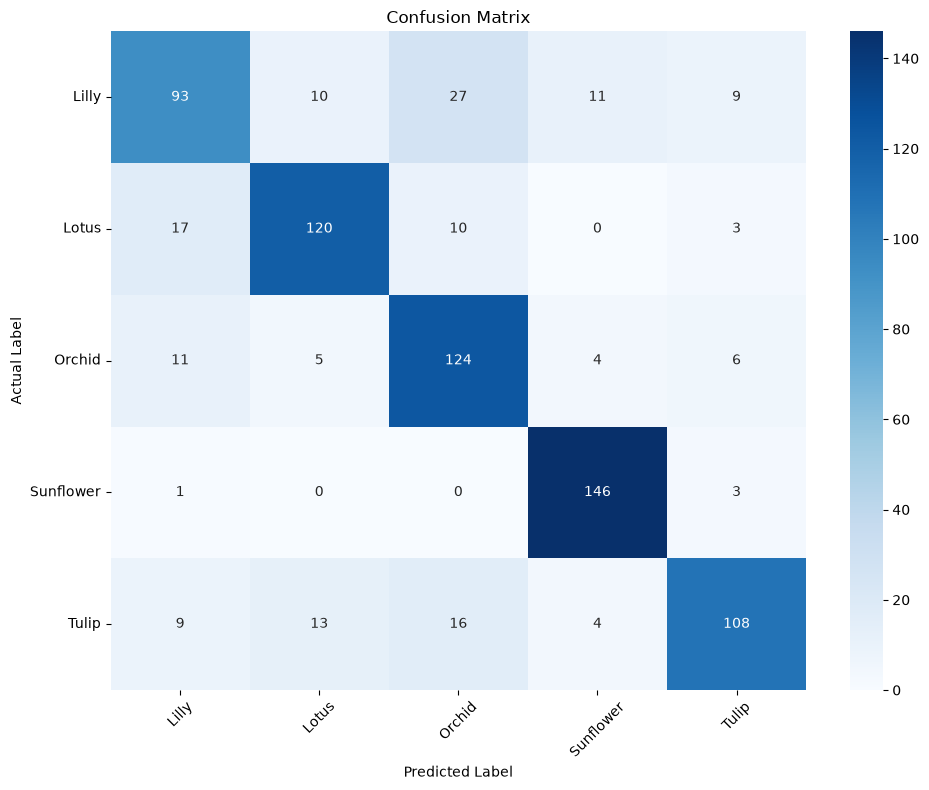

In [26]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.title(
    "Confusion Matrix"
)

plt.xticks(rotation=45)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

# 20. Visualize Model Predictions

In this section, we will visualize sample test images together with
their actual and predicted labels.

This helps us understand how the CNN performs on individual images.

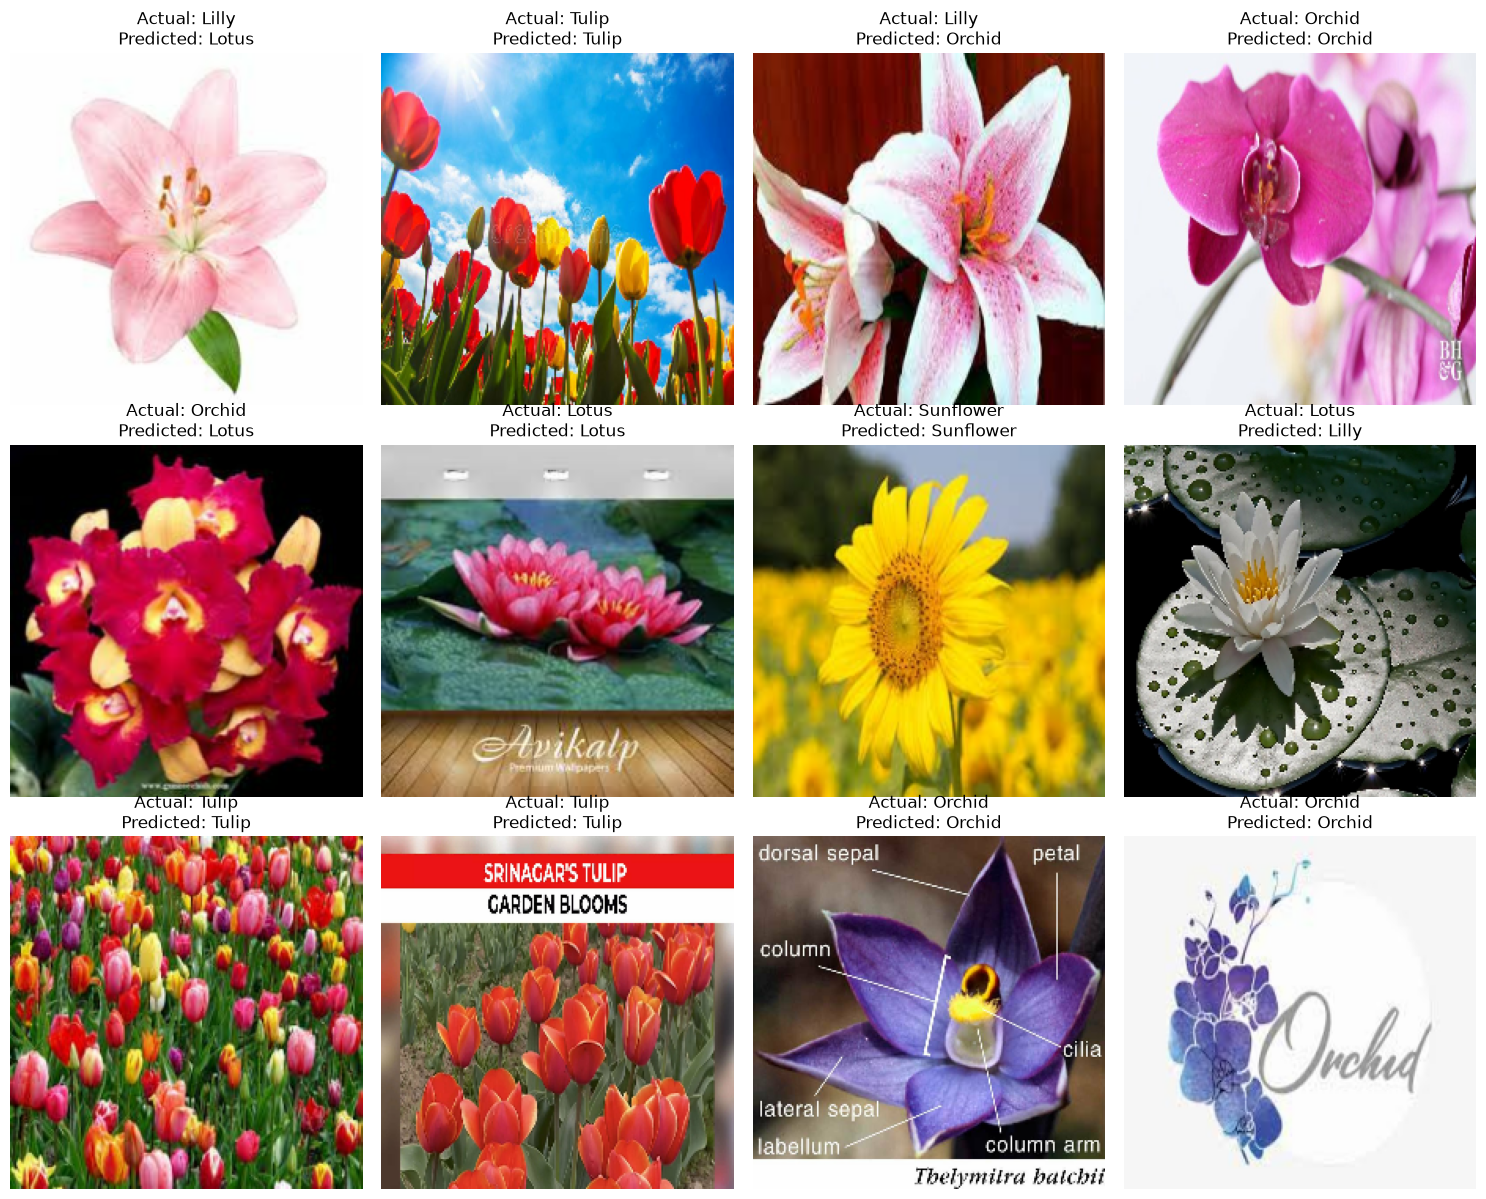

In [27]:
plt.figure(figsize=(15, 12))

for images, labels in test_ds.take(1):

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    for i in range(
        min(12, len(images))
    ):

        plt.subplot(3, 4, i + 1)

        plt.imshow(
            images[i].numpy()
        )

        actual = class_names[
            labels[i].numpy()
        ]

        predicted = class_names[
            predicted_labels[i]
        ]

        plt.title(
            f"Actual: {actual}\nPredicted: {predicted}"
        )

        plt.axis("off")

plt.tight_layout()

plt.show()

# 21. Single Image Prediction

We will now create a function that accepts a single flower image
and predicts its flower category.

The image will undergo the same preprocessing used during training.

The function will return:

- Predicted flower class
- Confidence score

In [28]:
def predict_image(
    image_path,
    model,
    class_names
):
    
    image = Image.open(
        image_path
    ).convert("RGB")
    
    image = image.resize(
        (224, 224)
    )
    
    image_array = np.array(
        image,
        dtype=np.float32
    ) / 255.0
    
    image_array = np.expand_dims(
        image_array,
        axis=0
    )
    
    predictions = model.predict(
        image_array,
        verbose=0
    )[0]
    
    predicted_index = np.argmax(
        predictions
    )
    
    predicted_class = class_names[
        predicted_index
    ]
    
    confidence = predictions[
        predicted_index
    ]
    
    return (
        predicted_class,
        confidence
    )

In [29]:
sample_image = train_df.iloc[0]["image_path"]

predicted_class, confidence = predict_image(
    sample_image,
    model,
    class_names
)

print(
    "Predicted Class:",
    predicted_class
)

print(
    f"Confidence: {confidence * 100:.2f}%"
)

Predicted Class: Sunflower
Confidence: 100.00%


# 23. Class Probability Analysis

The CNN produces a probability for every flower category.

We will display the probability assigned to each class to better
understand the model's prediction.

In [30]:
def predict_probabilities(
    image_path,
    model,
    class_names
):

    image = Image.open(
        image_path
    ).convert("RGB")

    image = image.resize(
        (224, 224)
    )

    image_array = np.array(
        image,
        dtype=np.float32
    ) / 255.0

    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    probabilities = model.predict(
        image_array,
        verbose=0
    )[0]

    results = []

    for class_name, probability in zip(
        class_names,
        probabilities
    ):
        
        results.append(
            (
                class_name,
                probability
            )
        )

    results.sort(
        key=lambda x: x[1],
        reverse=True
    )

    return results

In [31]:
results = predict_probabilities(
    sample_image,
    model,
    class_names
)

for class_name, probability in results:
    
    print(
        f"{class_name}: "
        f"{probability * 100:.2f}%"
    )

Sunflower: 100.00%
Tulip: 0.00%
Lilly: 0.00%
Lotus: 0.00%
Orchid: 0.00%


# 24. Save the Trained CNN Model

After training and evaluating the CNN, we will save the trained model.

The saved model can later be loaded without retraining and used inside
a Streamlit application.

In [32]:
model_path = (
    "flower_classification_cnn.keras"
)

model.save(
    model_path
)

print(
    "Model saved successfully!"
)

print(
    "Saved at:",
    model_path
)

Model saved successfully!
Saved at: flower_classification_cnn.keras


In [33]:
class_names = sorted(df["label"].unique())

print(class_names)

['Lilly', 'Lotus', 'Orchid', 'Sunflower', 'Tulip']


In [34]:
import json

with open("class_names.json", "w") as file:
    json.dump(class_names, file, indent=4)

print("Class names saved successfully!")

Class names saved successfully!
